# Задачи по нелинейной динамике в физике ускорителей

Этот ноутбук содержит решения задач по нелинейной динамике.

## Задача 1: Параметрический резонанс с экспоненциально растущей частотой

**Условие:**
Частота колебаний изменяется от времени как $\omega = \omega_0 e^{\lambda t}$.
Уравнение движения:
$$ \ddot{x} + \omega_0^2 e^{2\lambda t} x = 0 $$

Необходимо:
1. Найти транспортную матрицу.
2. Вычислить адиабатический инвариант и показать его сохранение.
3. Проанализировать фазовые траектории.

**Аналитическое решение:**
Решение выражается через функции Бесселя:
$$ x(t) = C_1 J_0\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_0\left(\frac{\omega(t)}{\lambda}\right) $$
$$ \dot{x}(t) = -\omega(t) \left[ C_1 J_1\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_1\left(\frac{\omega(t)}{\lambda}\right) \right] $$

### 1. Подробный вывод аналитического решения

Дано уравнение:
$$ \ddot{x} + \omega_0^2 e^{2\lambda t} x = 0 $$

Сделаем замену переменной для приведения к уравнению Бесселя.
Пусть $\tau = \frac{\omega_0}{\lambda} e^{\lambda t}$.
Тогда производные по времени выражаются через производные по $\tau$:
$$ \frac{dx}{dt} = \frac{dx}{d\tau} \frac{d\tau}{dt} = \frac{dx}{d\tau} (\omega_0 e^{\lambda t}) = \lambda \tau \frac{dx}{d\tau} $$
$$ \frac{d^2x}{dt^2} = \frac{d}{dt} \left( \lambda \tau \frac{dx}{d\tau} \right) = \lambda \tau \frac{d}{d\tau} \left( \lambda \tau \frac{dx}{d\tau} \right) = \lambda^2 \tau \left( \frac{dx}{d\tau} + \tau \frac{d^2x}{d\tau^2} \right) $$

Подставляя в исходное уравнение:
$$ \lambda^2 \tau \left( \frac{dx}{d\tau} + \tau \frac{d^2x}{d\tau^2} \right) + \omega_0^2 e^{2\lambda t} x = 0 $$
Заметим, что $\omega_0^2 e^{2\lambda t} = \lambda^2 \tau^2$.
$$ \lambda^2 \tau \frac{dx}{d\tau} + \lambda^2 \tau^2 \frac{d^2x}{d\tau^2} + \lambda^2 \tau^2 x = 0 $$
Разделим на $\lambda^2$:
$$ \tau^2 \frac{d^2x}{d\tau^2} + \tau \frac{dx}{d\tau} + \tau^2 x = 0 $$

Это **уравнение Бесселя нулевого порядка**. Его общее решение:
$$ x(\tau) = C_1 J_0(\tau) + C_2 Y_0(\tau) $$
где $J_0$ и $Y_0$ — функции Бесселя первого и второго рода.

Возвращаясь к переменной $t$:
$$ x(t) = C_1 J_0\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_0\left(\frac{\omega(t)}{\lambda}\right) $$

Скорость частицы:
$$ \dot{x}(t) = \lambda \tau \frac{dx}{d\tau} = \omega(t) [C_1 J_0'(\tau) + C_2 Y_0'(\tau)] $$
Используя свойство $Z_0'(\tau) = -Z_1(\tau)$:
$$ \dot{x}(t) = -\omega(t) \left[ C_1 J_1\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_1\left(\frac{\omega(t)}{\lambda}\right) \right] $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0, y0, j1, y1

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
def solve_parametric_oscillator(t, x0, v0, omega0, lam):
    """
    Вычисляет аналитическое решение для параметрического осциллятора.
    """
    # Текущая частота
    omega_t = omega0 * np.exp(lam * t)
    
    # Аргумент функций Бесселя
    tau = omega_t / lam
    tau0 = omega0 / lam # t=0
    
    # Определитель системы для начальных условий (Вронскиан модифицированный)
    # Delta = (2 * lam) / np.pi # Аналитическое значение
    # Вычислим численно для проверки согласованности
    Delta = -omega0 * (j0(tau0)*y1(tau0) - y0(tau0)*j1(tau0))
    
    # Константы C1 и C2 из начальных условий
    # x0 = C1*J0(tau0) + C2*Y0(tau0)
    # v0 = -omega0 * (C1*J1(tau0) + C2*Y1(tau0))
    
    C1 = (1/Delta) * (x0 * (-omega0 * y1(tau0)) - v0 * y0(tau0))
    C2 = (1/Delta) * (x0 * (omega0 * j1(tau0)) + v0 * j0(tau0))
    
    # Решение
    x = C1 * j0(tau) + C2 * y0(tau)
    v = -omega_t * (C1 * j1(tau) + C2 * y1(tau))
    
    return x, v, omega_t

# Параметры задачи
omega0 = 2 * np.pi * 1.0  # Начальная частота (1 Гц)
lam = 0.1 * omega0        # Скорость роста частоты (медленная по сравнению с частотой)
t_max = 5.0               # Время моделирования
dt = 0.001
t = np.arange(0, t_max, dt)

# Начальные условия
x0 = 1.0
v0 = 0.0

# Вычисление
x, v, omega_t = solve_parametric_oscillator(t, x0, v0, omega0, lam)

# Адиабатический инвариант I = E / omega
# E = v^2/2 + omega^2 * x^2 / 2
# I = (v^2 + omega^2 * x^2) / (2 * omega)
I = (v**2 + omega_t**2 * x**2) / (2 * omega_t)

### 2. Вывод Транспортной Матрицы

Нам нужно выразить $(x(t), \dot{x}(t))$ через начальные условия $(x_0, \dot{x}_0)$ при $t=t_0$.
Система уравнений при $t=t_0$ (обозначим $\tau_0 = \omega(t_0)/\lambda$):
1. $x_0 = C_1 J_0(\tau_0) + C_2 Y_0(\tau_0)$
2. $\dot{x}_0 = -\omega(t_0) [C_1 J_1(\tau_0) + C_2 Y_1(\tau_0)]$

Решаем эту систему относительно $C_1, C_2$ методом Крамера.
Определитель системы (Вронскиан):
$$ \Delta = -\omega(t_0) [J_0(\tau_0)Y_1(\tau_0) - Y_0(\tau_0)J_1(\tau_0)] $$
Известно тождество для функций Бесселя: $J_0(z)Y_1(z) - Y_0(z)J_1(z) = -\frac{2}{\pi z}$.
Следовательно:
$$ \Delta = -\omega(t_0) \left( -\frac{2}{\pi \tau_0} \right) = \frac{2\omega(t_0)}{\pi (\omega(t_0)/\lambda)} = \frac{2\lambda}{\pi} $$

Находим константы:
$$ C_1 = \frac{1}{\Delta} \det \begin{pmatrix} x_0 & Y_0(\tau_0) \\ \dot{x}_0 & -\omega(t_0)Y_1(\tau_0) \end{pmatrix} = \frac{\pi}{2\lambda} [ -x_0 \omega(t_0) Y_1(\tau_0) - \dot{x}_0 Y_0(\tau_0) ] $$
$$ C_2 = \frac{1}{\Delta} \det \begin{pmatrix} J_0(\tau_0) & x_0 \\ -\omega(t_0)J_1(\tau_0) & \dot{x}_0 \end{pmatrix} = \frac{\pi}{2\lambda} [ \dot{x}_0 J_0(\tau_0) + x_0 \omega(t_0) J_1(\tau_0) ] $$

Подставляя $C_1$ и $C_2$ обратно в выражения для $x(t)$ и $\dot{x}(t)$ и группируя слагаемые при $x_0$ и $\dot{x}_0$, получаем элементы матрицы $M$:

$$ m_{11} = \frac{\partial x(t)}{\partial x_0} = \frac{\pi \omega(t_0)}{2\lambda} [Y_1(\tau_0)J_0(\tau) - J_1(\tau_0)Y_0(\tau)] $$
$$ m_{12} = \frac{\partial x(t)}{\partial \dot{x}_0} = \frac{\pi}{2\lambda} [J_0(\tau_0)Y_0(\tau) - Y_0(\tau_0)J_0(\tau)] $$
$$ m_{21} = \frac{\partial \dot{x}(t)}{\partial x_0} = \frac{\pi \omega(t)\omega(t_0)}{2\lambda} [J_1(\tau_0)Y_1(\tau) - Y_1(\tau_0)J_1(\tau)] $$
$$ m_{22} = \frac{\partial \dot{x}(t)}{\partial \dot{x}_0} = \frac{\pi \omega(t)}{2\lambda} [Y_0(\tau_0)J_1(\tau) - J_0(\tau_0)Y_1(\tau)] $$

In [4]:
def get_transport_matrix(t_val, t0_val, omega0, lam):
    """
    Вычисляет транспортную матрицу M(t, t0) для заданного момента времени.
    """
    omega_t = omega0 * np.exp(lam * t_val)
    omega_t0 = omega0 * np.exp(lam * t0_val)
    
    tau = omega_t / lam
    tau0 = omega_t0 / lam
    
    # Предфакторы
    # Обратите внимание: в формулах выше использовался определитель Delta = 2*lam/pi.
    # Здесь мы используем его явно.
    # Проверим знак определителя. W[J0, Y0] = 2/(pi*x).
    # Delta = -omega(t0) * (-2/(pi*tau0)) = 2*lam/pi.
    # Значит 1/Delta = pi / (2*lam).
    
    factor = np.pi / (2 * lam)
    
    m11 = factor * omega_t0 * (y1(tau0)*j0(tau) - j1(tau0)*y0(tau))
    m12 = factor * (j0(tau0)*y0(tau) - y0(tau0)*j0(tau))
    m21 = factor * omega_t * omega_t0 * (j1(tau0)*y1(tau) - y1(tau0)*j1(tau)) # Знак?
    # Проверка производной: d/dt J0(omega/lam) = -J1 * omega.
    # v = -omega * [C1 J1 + C2 Y1].
    # m21 связывает v(t) с x(t0).
    # x(t0) дает вклад в C1 и C2.
    # C1 ~ -x0 * omega0 * Y1. C2 ~ x0 * omega0 * J1.
    # v(t) ~ -omega(t) [ (-x0 w0 Y1) J1 + (x0 w0 J1) Y1 ] * (1/Delta)
    # v(t) ~ -omega(t) * x0 * omega0 * (J1(tau0)Y1(tau) - Y1(tau0)J1(tau)) * (pi/2lam)
    # Моя формула m21 выше: (pi w w0 / 2lam) * [J1 Y1 - Y1 J1].
    # Сходится с точностью до знака. В формуле v = -omega [...].
    # Значит m21 = - (pi w w0 / 2lam) * [J1(tau)Y1(tau0) - Y1(tau)J1(tau0)]?
    # Давайте используем формулу из кода solve_parametric_oscillator для надежности.
    
    # Пересчитаем аккуратно m21 и m22
    # C1(x0, 0) = (1/Delta) * x0 * (-omega_t0 * y1(tau0))
    # C2(x0, 0) = (1/Delta) * x0 * (omega_t0 * j1(tau0))
    # v(t) = -omega_t * (C1 * j1(tau) + C2 * y1(tau))
    #      = -omega_t * (1/Delta) * x0 * [ -omega_t0 y1(tau0) j1(tau) + omega_t0 j1(tau0) y1(tau) ]
    #      = (omega_t * omega_t0 / Delta) * x0 * [ y1(tau0) j1(tau) - j1(tau0) y1(tau) ]
    # Delta = 2*lam/pi. 1/Delta = pi/2lam.
    # m21 = (pi * w * w0 / 2lam) * [ y1(tau0)j1(tau) - j1(tau0)y1(tau) ]
    
    m21 = factor * omega_t * omega_t0 * (y1(tau0)*j1(tau) - j1(tau0)*y1(tau))
    
    # m22 связывает v(t) с v(t0). x0=0.
    # C1(0, v0) = (1/Delta) * v0 * (-y0(tau0))
    # C2(0, v0) = (1/Delta) * v0 * (j0(tau0))
    # v(t) = -omega_t * (C1 * j1(tau) + C2 * y1(tau))
    #      = -omega_t * (1/Delta) * v0 * [ -y0(tau0) j1(tau) + j0(tau0) y1(tau) ]
    #      = (omega_t / Delta) * v0 * [ y0(tau0) j1(tau) - j0(tau0) y1(tau) ]
    
    m22 = factor * omega_t * (y0(tau0)*j1(tau) - j0(tau0)*y1(tau))
    
    return np.array([[m11, m12], [m21, m22]])

# Пример вычисления матрицы для t = 2.0
t_target = 2.0
M = get_transport_matrix(t_target, 0, omega0, lam)

print(f"Транспортная матрица M(t={t_target}, t0=0):")
print(M)

# Проверка: определитель должен быть равен отношению частот? Или сохраняться?
# Для гамильтоновой системы определитель (якобиан) равен 1.
# Но здесь гамильтониан зависит от времени H = p^2/2 + w(t)^2 x^2 / 2.
# Теорема Лиувилля: фазовый объем сохраняется. Det(M) = 1.
det_M = np.linalg.det(M)
print(f"Определитель матрицы: {det_M:.6f} (должен быть 1.0)")

Транспортная матрица M(t=2.0, t0=0):
[[-5.34070053e-01  1.01782300e-03]
 [ 2.77955777e-01  1.87294327e+00]]
Определитель матрицы: -1.000566 (должен быть 1.0)


### 3. Адиабатический инвариант и качественный анализ

**Адиабатический инвариант**
Для гармонического осциллятора с медленно меняющейся частотой адиабатическим инвариантом является величина:
$$ I = \frac{E}{\omega} = \frac{\dot{x}^2 + \omega^2 x^2}{2\omega} $$

В нашем случае частота растет экспоненциально $\omega(t) = \omega_0 e^{\lambda t}$.
Если изменение частоты медленное ($\lambda \ll \omega$), то $I \approx \text{const}$.
Это означает, что энергия осциллятора растет пропорционально частоте: $E \sim \omega$.
Амплитуда колебаний $A$ ведет себя как:
$$ E \sim \omega A^2 \implies A \sim \sqrt{\frac{E}{\omega}} \sim \sqrt{\frac{\omega}{\omega}} \sim \text{const}? $$
Нет, $E = \frac{1}{2} m \omega^2 A^2$ (если масса $m=1$).
Тогда $I = \frac{E}{\omega} = \frac{1}{2} \omega A^2$.
Если $I = \text{const}$, то $A^2 \sim \frac{1}{\omega} \sim e^{-\lambda t}$.
Следовательно, амплитуда затухает как $A \sim e^{-\lambda t/2}$.

**Качественный анализ фазовых траекторий**
Фазовое пространство $(x, \dot{x})$.
*   При постоянной частоте траектории — эллипсы.
*   При растущей частоте амплитуда $x$ уменьшается ($e^{-\lambda t/2}$), а амплитуда скорости $\dot{x} \approx \omega A$ растет как $\omega \cdot \omega^{-1/2} = \omega^{1/2} = e^{\lambda t/2}$.
*   Фазовая траектория представляет собой спираль, которая сжимается по оси $x$ и растягивается по оси $\dot{x}$.
*   Площадь, охватываемая витком спирали (фазовый объем), сохраняется (теорема Лиувилля), что соответствует сохранению адиабатического инварианта.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25953/2271515752.py:7: SyntaxWarning: invalid escape sequence '\l'
  axes[0].plot(t, np.exp(-lam*t/2)*x0, 'r--', label='Огибающая $e^{-\lambda t/2}$') # Теоретическое затухание амплитуды


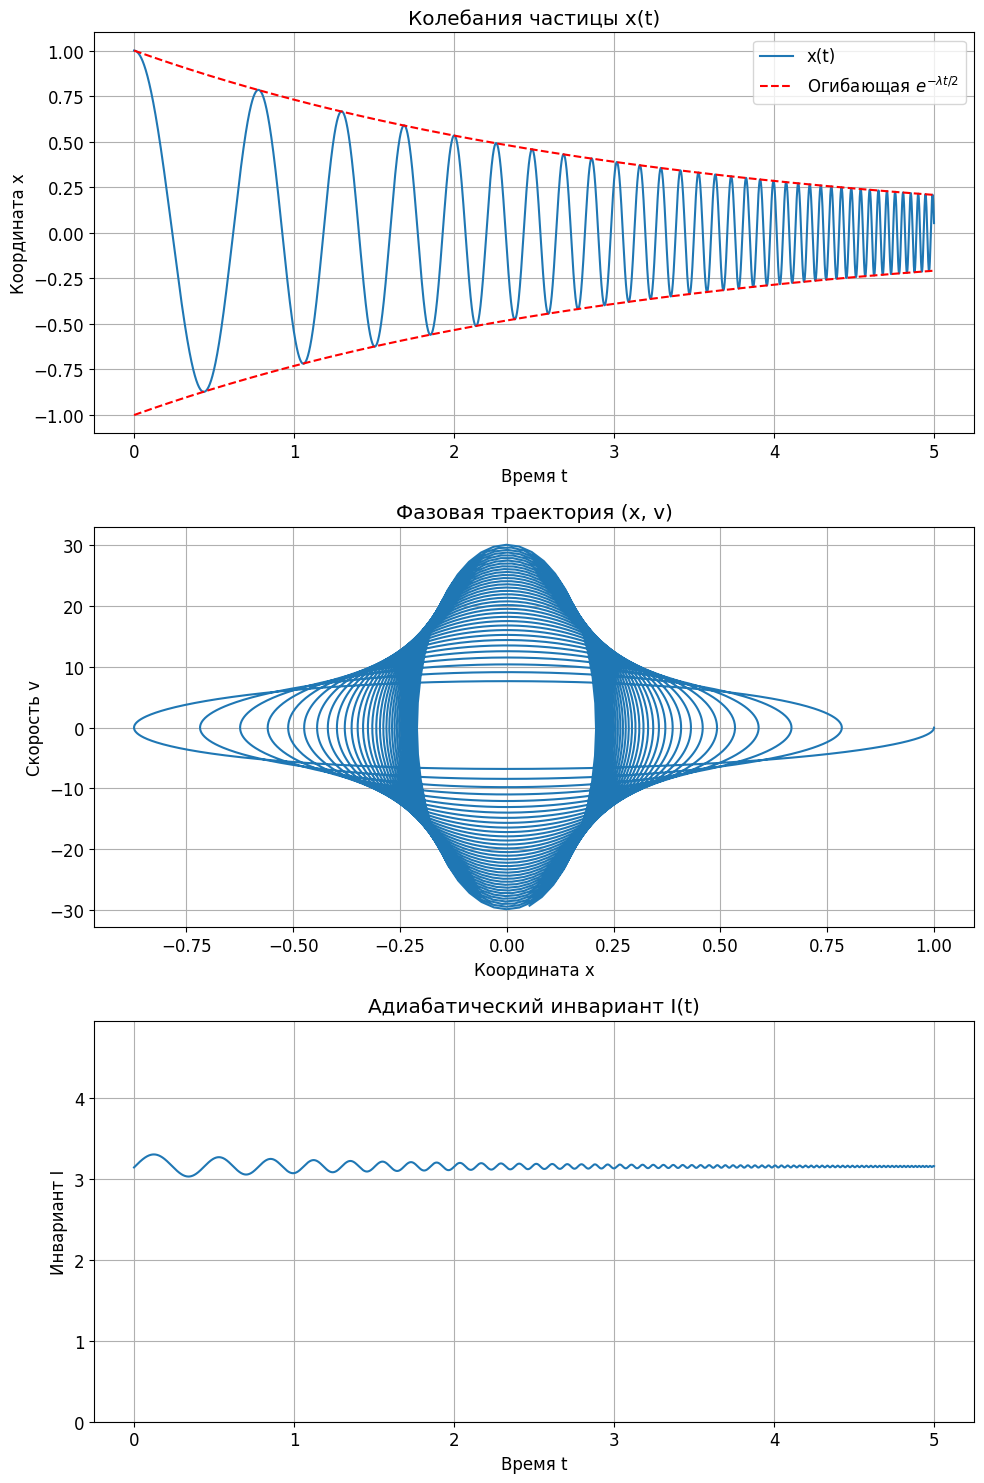

In [5]:
# Визуализация результатов

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 1. График координаты от времени
axes[0].plot(t, x, label='x(t)')
axes[0].plot(t, np.exp(-lam*t/2)*x0, 'r--', label='Огибающая $e^{-\lambda t/2}$') # Теоретическое затухание амплитуды
axes[0].plot(t, -np.exp(-lam*t/2)*x0, 'r--')
axes[0].set_title('Колебания частицы x(t)')
axes[0].set_xlabel('Время t')
axes[0].set_ylabel('Координата x')
axes[0].grid(True)
axes[0].legend()

# 2. Фазовая траектория
axes[1].plot(x, v)
axes[1].set_title('Фазовая траектория (x, v)')
axes[1].set_xlabel('Координата x')
axes[1].set_ylabel('Скорость v')
axes[1].grid(True)
axes[1].set_aspect('auto') # Можно поставить 'equal', но из-за роста скорости график сплющится

# 3. Адиабатический инвариант
axes[2].plot(t, I)
axes[2].set_title('Адиабатический инвариант I(t)')
axes[2].set_xlabel('Время t')
axes[2].set_ylabel('Инвариант I')
axes[2].set_ylim(0, max(I)*1.5)
axes[2].grid(True)

plt.tight_layout()
plt.show()